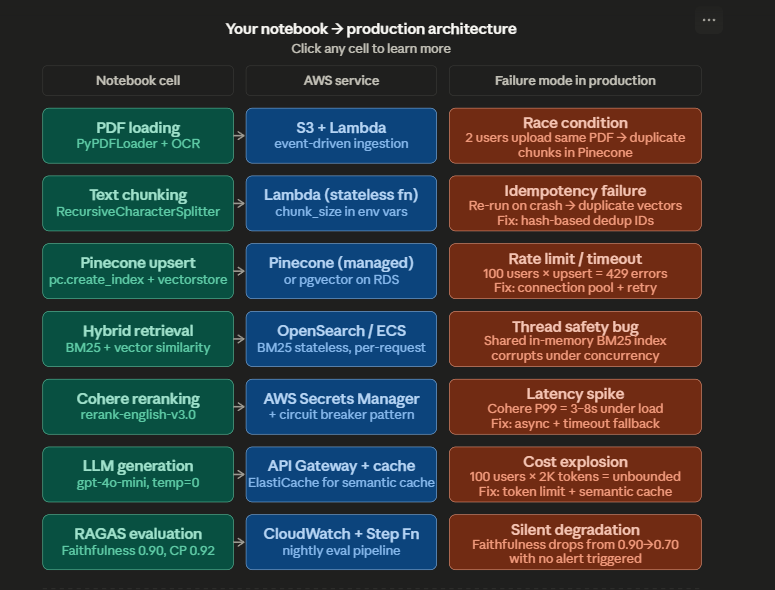

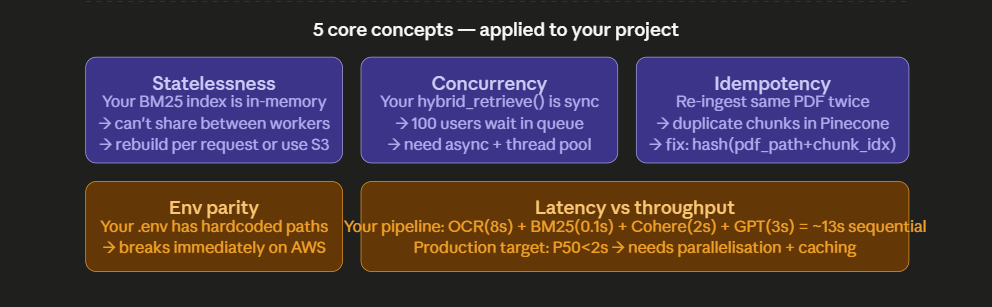

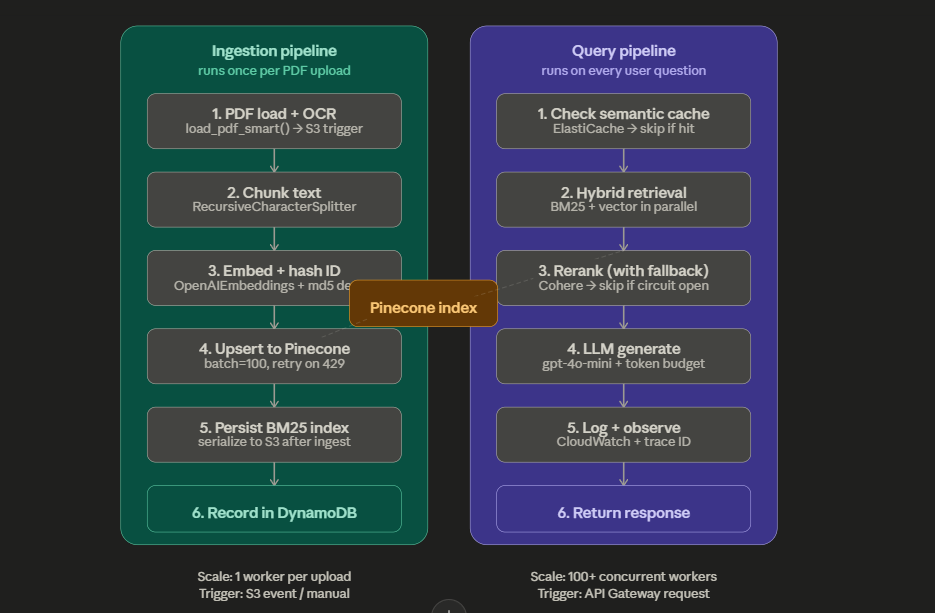

### Circuit Breaker Pattern - Cohere

#### 🧠 Why you need it (your RAG context)

##### In your Legal_Lense pipeline, you depend on:

- OpenAI → LLM
- Cohere → reranking
- Pinecone → vector DB

- Now imagine:

- Cohere API becomes slow or starts failing ❌

##### Without circuit breaker:

- Your system keeps retrying
- Latency increases ⬆️
- Threads get blocked
- Entire pipeline slows down or crashes

##### 🔥 With Circuit Breaker

👉 After repeated failures:

- Stop calling Cohere temporarily
- Use fallback (e.g., skip reranking or use BM25 only)

#### idempotent hash IDs

This is the most important new concept. Your notebook had no deduplication — re-ingesting would create duplicate vectors. The fix is hashing each chunk's content to create a stable ID.

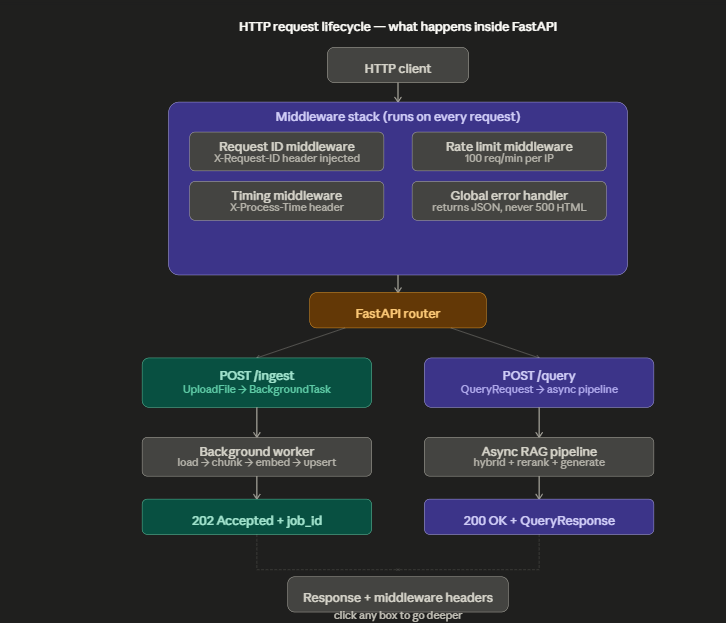

- Concept 1 — Why async matters for your RAG pipeline

Your Hour 2 run_rag_query() is synchronous. This means if 10 users call /query at the same time, requests queue up — user 10 waits for users 1–9 to finish. With async, all 10 pipeline runs start nearly simultaneously and Python switches between them during I/O waits (the Pinecone network call, the OpenAI API call, the Cohere call). Your pipeline is almost entirely I/O bound — the CPU is idle most of the time waiting for API responses. Async turns that idle time into work for other requests.

- The mental model: synchronous is a single cashier serving one customer at a time. Async is one cashier who starts each customer's order, then turns to the next while the coffee machine runs.

- Step 1 — src/api/schemas.py
Pydantic models are the contract between your API and its callers. Every request and response is validated here before any code runs.

- Step 2 — src/api/dependencies.py
This is the most important architectural decision of Hour 3: shared expensive state (the Pinecone connection, the loaded chunks, the embedding model) should be created once when the app starts, not on every request. FastAPI's dependency injection system handles this cleanly.

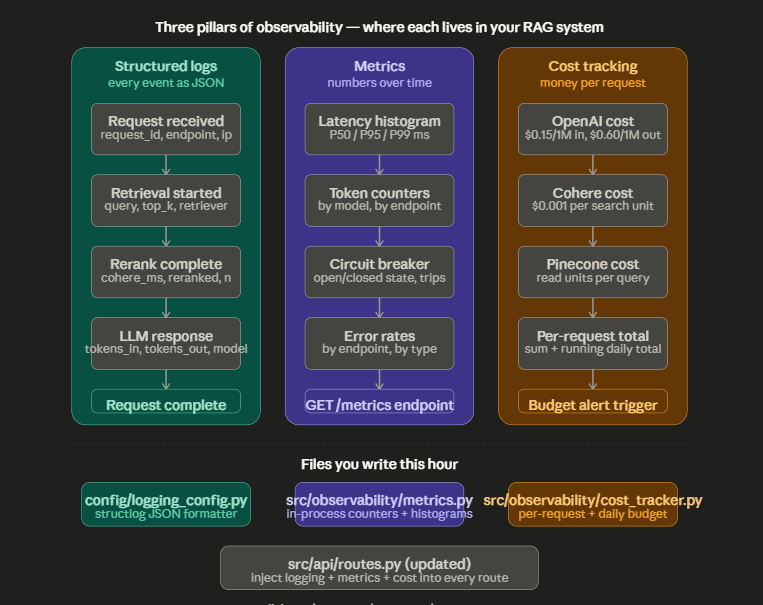

- Concept 1 — Why print() is not logging

Your current code uses print(f"[ingest] ...") everywhere. In production this is fatal for three reasons. First, print output is unstructured — you can't query "show me all requests where latency > 3000ms" because the data is buried in a string. Second, there is no severity — you can't filter warnings from debug noise. Third, there is no context propagation — the request_id from your middleware never automatically appears in nested function calls.

Structured logging means every log line is a JSON object. Instead of "[query] request_id=abc latency=2847ms reranked=True", you get:

{
  "timestamp": "2025-04-17T08:23:11Z",
  "level": "info",
  "event": "query_complete",
  "request_id": "a3f2c1d8",
  "latency_ms": 2847,
  "reranked": true,
  "model": "gpt-4o-mini",
  "tokens_in": 412,
  "tokens_out": 87,
  "cost_usd": 0.000114
}

CloudWatch, Datadog, and every log analysis tool can then query this like a database.

- Step 2 — src/observability/metrics.py

This is an in-process metrics store — no external service needed. It tracks latency distributions, counts, and error rates entirely in memory. In production you'd push these to CloudWatch or Prometheus, but this structure lets you do that later without changing any call sites.

### Test Suite

- Why a test suite — the real reason, not the textbook reason

Right now you change code and manually call curl to check if it still works. That takes 2 minutes per check and you can only test one thing at a time. A test suite lets you run 30 checks in under 5 seconds, automatically, every time you change anything. More importantly: your RAG pipeline calls Pinecone, OpenAI, and Cohere — those are expensive. Every manual test costs money. Tests with mocks cost zero.

The second reason specific to ML systems: your pipeline has silent correctness failures. If your hybrid_retrieve() accidentally weights BM25 at 0.6 and vector at 0.4 (swapped from the correct values), the API still returns 200 OK. Users get slightly worse answers. Without a test that asserts the exact weights, you'll never catch it. Tests make your intent explicit and verifiable.

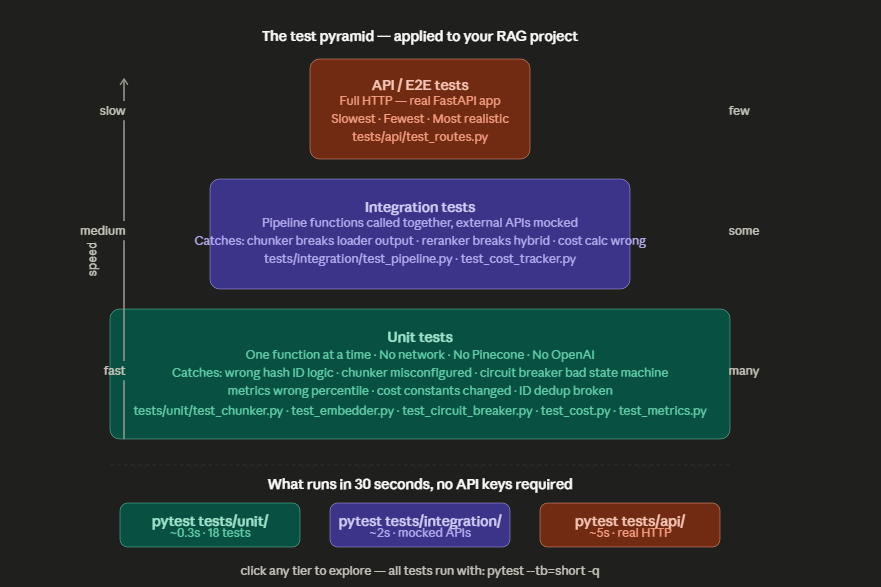

- tests/conftest.py — shared fixtures

Fixtures in conftest.py are available to every test file automatically. They are the "setup" that runs before each test and "teardown" that runs after.

### Containarization

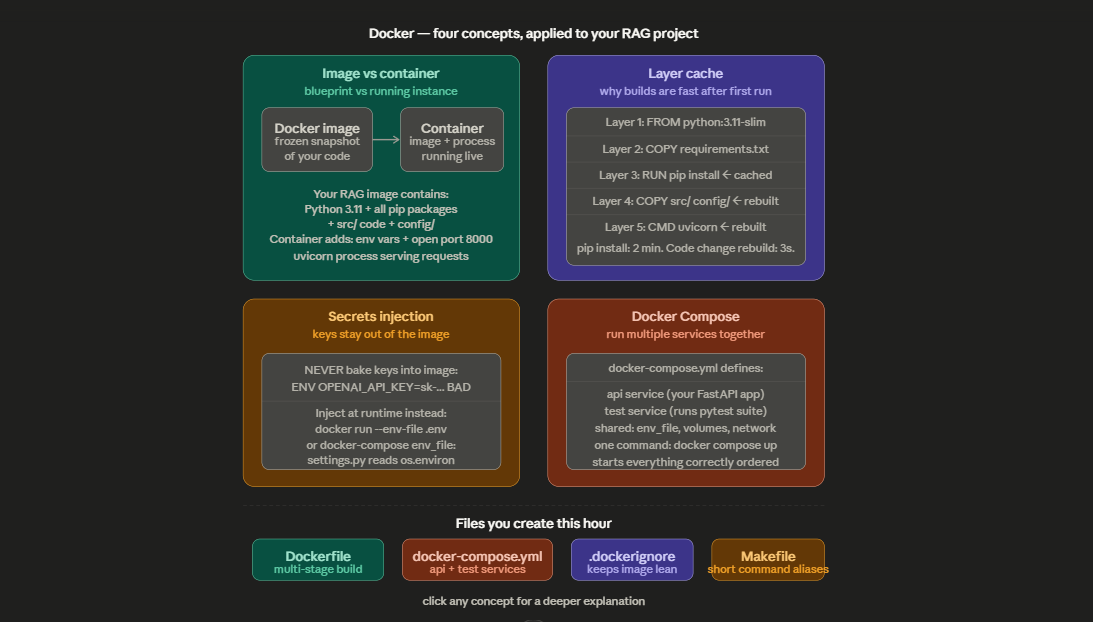

Image layers and the cache are the most important thing to understand before writing your Dockerfile. Every instruction (FROM, COPY, RUN) creates a layer. Docker caches each layer — if the layer's inputs haven't changed since last build, it reuses the cached output instead of re-running. The consequence: if you COPY requirements.txt then RUN pip install before copying your source code, then editing chunker.py only invalidates layers 4 and 5 — the pip install layer (which takes 2 minutes) is reused from cache. If you copy everything first and then pip install, every code change forces a full reinstall. Layer order is a performance decision.

Containers are ephemeral by default. When a container stops, any data written inside it is lost. This matters for your RAG system: if the ingestion background task stores chunks in-memory and the container restarts, those chunks are gone. In this hour you'll mount a data/ volume so PDF files persist. The Pinecone vectors are already persistent because they live outside the container in Pinecone's infrastructure.

Environment variables are the configuration contract between Docker and your application. Your config/settings.py already uses BaseSettings which reads from environment variables — that is the correct production pattern. In Docker, you pass those variables at runtime with --env-file .env or in docker-compose.yml, never by baking them into the image layer.

# Put your PDF in the mounted data directory
# On your host machine, Docker volumes are accessible — find the path:
docker volume inspect legal-lense_rag_data

# Or more practically — copy a file into the running container:
docker compose exec api mkdir -p data/raw
docker cp data/raw/sample_rent.pdf $(docker compose ps -q api):/app/data/raw/

# Ingest it via the API
curl -X POST http://localhost:8000/api/v1/ingest/path \
  -H "Content-Type: application/json" \
  -d '{"pdf_path": "data/raw/sample_rent.pdf"}'

# Wait 10 seconds, then query
sleep 10
curl -X POST http://localhost:8000/api/v1/query \
  -H "Content-Type: application/json" \
  -d '{"question": "What is the monthly rent amount?"}'

chmod +x infrastructure/deploy.sh

### Scaling

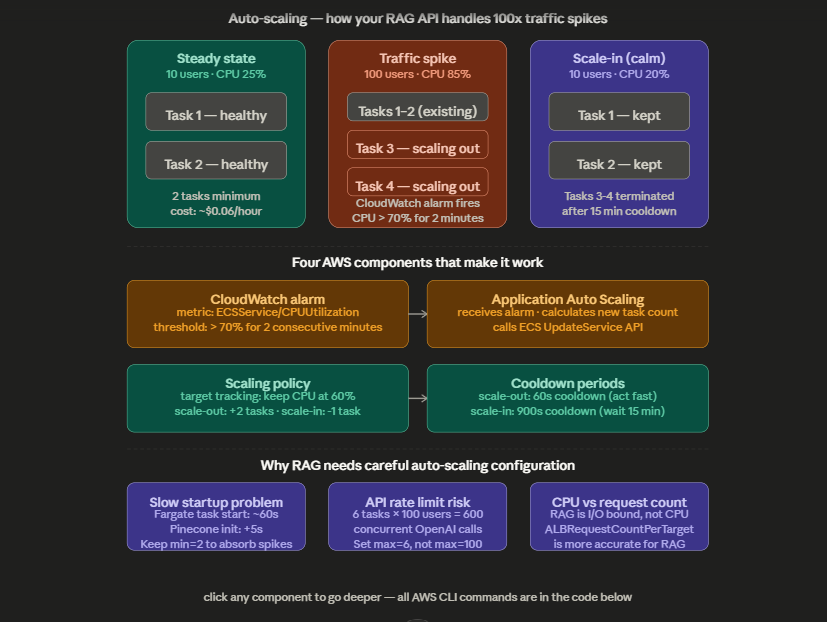

- Why auto-scaling — the real problem it solves

Right now your ECS service runs exactly 2 tasks permanently. At 2am when no one uses it, you're paying for 2 tasks. At 2pm when 100 users hit it simultaneously, you're still running 2 tasks — all 100 requests pile up, latency spikes to 60 seconds, users see timeouts. Auto-scaling fixes both problems: it adds tasks automatically when traffic increases and removes them automatically when it drops. You pay for exactly what you use, and users always get fast responses.

For your RAG system specifically, auto-scaling has a complication that simple web APIs don't have: each ECS task calls OpenAI, Pinecone, and Cohere. Scaling to 20 tasks under sudden load means 20× as many API calls — you can hit OpenAI's rate limits very quickly. So the scaling configuration for a RAG system needs tighter maximums and smarter metrics than a typical CRUD API.

The four core concepts in detail

Target tracking scaling policy is the most important concept here, and the simplest to configure correctly. You say "keep CPU at 60%" and AWS figures out exactly how many tasks to add or remove to maintain that target. You don't write rules like "if CPU > 70% add 2 tasks, if CPU > 90% add 5 tasks" — you just set the target and the math is automatic. This is what you'll use.
Cooldown periods are intentional delays between scaling actions. Scale-out cooldown (60s by default) is short — when traffic spikes, you want to add capacity quickly. Scale-in cooldown (900s default) is long — when traffic drops, you wait 15 minutes before removing tasks. The asymmetry is deliberate: scaling in too aggressively means a second wave of traffic hits a reduced fleet, causing another spike. For RAG systems that have slow task startups, a long scale-in cooldown is essential.
Scale-out vs scale-in protection is a feature that prevents ECS from terminating a task that is actively serving a long-running request. Your RAG queries can take 3–8 seconds. Without scale-in protection, ECS might terminate a task mid-request when scaling down. With protection enabled, the task finishes its current request before being terminated.
Metrics choice is where RAG differs from normal APIs. CPU is a common scaling metric, but RAG is I/O-bound — your CPU is idle most of the time while waiting for OpenAI/Pinecone/Cohere to respond. A task can be handling 20 concurrent requests while showing only 15% CPU. The ALBRequestCountPerTarget metric (requests per task per minute) is more accurate for RAG: it directly measures load, not CPU.

In [1]:
import os
os.path.join(os.path.dirname(__file__), "../../frontend/index.html")

NameError: name '__file__' is not defined